# Actividad 19

## 1. Importar librerías

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import time

## 2. Función objetivo

In [46]:
def f(x, y):
    """Función objetivo a maximizar."""
    return 21.5 + x * np.sin(4 * np.pi * x) + y * np.sin(20 * np.pi * y)

x_min, x_max = -3.0, 12.1
y_min, y_max =  4.1,  5.8

print("Función objetivo definida ✓")

Función objetivo definida ✓


## 3. Solución por programación estructurada (búsqueda exhaustiva)

In [47]:
# Resolución de la malla
N_puntos = 5000

t0 = time.time()

x_grid = np.linspace(x_min, x_max, N_puntos)
y_grid = np.linspace(y_min, y_max, N_puntos)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)
Z_grid = f(X_grid, Y_grid)

# Encontrar el máximo
idx_max = np.unravel_index(np.argmax(Z_grid), Z_grid.shape)
x_best_grid = X_grid[idx_max]
y_best_grid = Y_grid[idx_max]
f_best_grid = Z_grid[idx_max]

t_grid = time.time() - t0

print(f"=== Búsqueda Exhaustiva (Grid Search) ===")
print(f"Resolución       : {N_puntos} x {N_puntos} = {N_puntos**2:,} evaluaciones")
print(f"Mejor f(x,y)     : {f_best_grid:.6f}")
print(f"x                : {x_best_grid:.6f}")
print(f"y                : {y_best_grid:.6f}")
print(f"Tiempo           : {t_grid:.4f} s")

=== Búsqueda Exhaustiva (Grid Search) ===
Resolución       : 5000 x 5000 = 25,000,000 evaluaciones
Mejor f(x,y)     : 38.850026
x                : 11.625765
y                : 5.725185
Tiempo           : 0.2950 s


### 4. Parámetros del PSO

In [48]:
N_particulas = 50
N_iteraciones = 300
w_max = 0.9
w_min = 0.4
c1    = 2.0
c2    = 2.0
Ndim  = 2

# Límites del dominio
limites_inf = np.array([x_min, y_min])
limites_sup = np.array([x_max, y_max])

# Velocidad máxima
v_max = 0.5 * (limites_sup - limites_inf)

print("Parámetros del PSO definidos ✓")
print(f"  Partículas  : {N_particulas}")
print(f"  Iteraciones : {N_iteraciones}")
print(f"  w: {w_max} → {w_min} (decreciente lineal)")
print(f"  c1={c1}, c2={c2}")

Parámetros del PSO definidos ✓
  Partículas  : 50
  Iteraciones : 300
  w: 0.9 → 0.4 (decreciente lineal)
  c1=2.0, c2=2.0


### 4.1 Inicialización del enjambre

In [49]:
np.random.seed(42)

# Posiciones aleatorias
posiciones = limites_inf + np.random.rand(N_particulas, Ndim) * (limites_sup - limites_inf)

# Velocidades iniciales aleatorias pequeñas
velocidades = np.random.uniform(-1, 1, size=(N_particulas, Ndim)) * v_max * 0.1

# Aptitud inicial
aptitudes = f(posiciones[:, 0], posiciones[:, 1])

# Mejor posición personal (pbest)
pbest_pos = posiciones.copy()
pbest_val = aptitudes.copy()

# Mejor posición global (gbest)
idx_gbest  = np.argmax(pbest_val)
gbest_pos  = pbest_pos[idx_gbest].copy()
gbest_val  = pbest_val[idx_gbest]

print(f"Enjambre inicializado ✓")
print(f"  Mejor aptitud inicial: {gbest_val:.6f}")
print(f"  Posición: x={gbest_pos[0]:.6f}, y={gbest_pos[1]:.6f}")

Enjambre inicializado ✓
  Mejor aptitud inicial: 37.775746
  Posición: x=11.640728, y=5.417726


### 4.2 Ciclo principal del PSO

In [50]:
historial_gbest = np.zeros(N_iteraciones)
historial_posiciones = []

t0 = time.time()

for t in range(N_iteraciones):

    # Peso de inercia decreciente linealmente
    w = w_max - (w_max - w_min) * t / N_iteraciones

    # Números aleatorios
    r1 = np.random.rand(N_particulas, Ndim)
    r2 = np.random.rand(N_particulas, Ndim)

    # Actualizar velocidades
    velocidades = (w * velocidades
                   + c1 * r1 * (pbest_pos - posiciones)
                   + c2 * r2 * (gbest_pos - posiciones))

    # Limitar velocidad máxima
    velocidades = np.clip(velocidades, -v_max, v_max)

    # Actualizar posiciones
    posiciones = posiciones + velocidades

    # Mantener partículas dentro del dominio
    posiciones = np.clip(posiciones, limites_inf, limites_sup)

    # Evaluar aptitud
    aptitudes = f(posiciones[:, 0], posiciones[:, 1])

    # Actualizar pbest
    mejora = aptitudes > pbest_val
    pbest_pos[mejora] = posiciones[mejora]
    pbest_val[mejora] = aptitudes[mejora]

    # Actualizar gbest
    idx_mejor = np.argmax(pbest_val)
    if pbest_val[idx_mejor] > gbest_val:
        gbest_pos = pbest_pos[idx_mejor].copy()
        gbest_val = pbest_val[idx_mejor]

    historial_gbest[t] = gbest_val

    # Guardar posiciones cada 10 iteraciones para visualización
    if t % 10 == 0:
        historial_posiciones.append(posiciones.copy())

t_pso = time.time() - t0

# Total de evaluaciones de la función
total_eval_pso = N_particulas * N_iteraciones

print(f"=== Enjambre de Partículas (PSO) ===")
print(f"Evaluaciones     : {total_eval_pso:,}")
print(f"Mejor f(x,y)     : {gbest_val:.6f}")
print(f"x                : {gbest_pos[0]:.6f}")
print(f"y                : {gbest_pos[1]:.6f}")
print(f"Tiempo           : {t_pso:.4f} s")

=== Enjambre de Partículas (PSO) ===
Evaluaciones     : 15,000
Mejor f(x,y)     : 38.732806
x                : 12.100000
y                : 5.725044
Tiempo           : 0.0229 s


## 5. Gráficas

### 5.1 Superficie 3D con óptimo del PSO

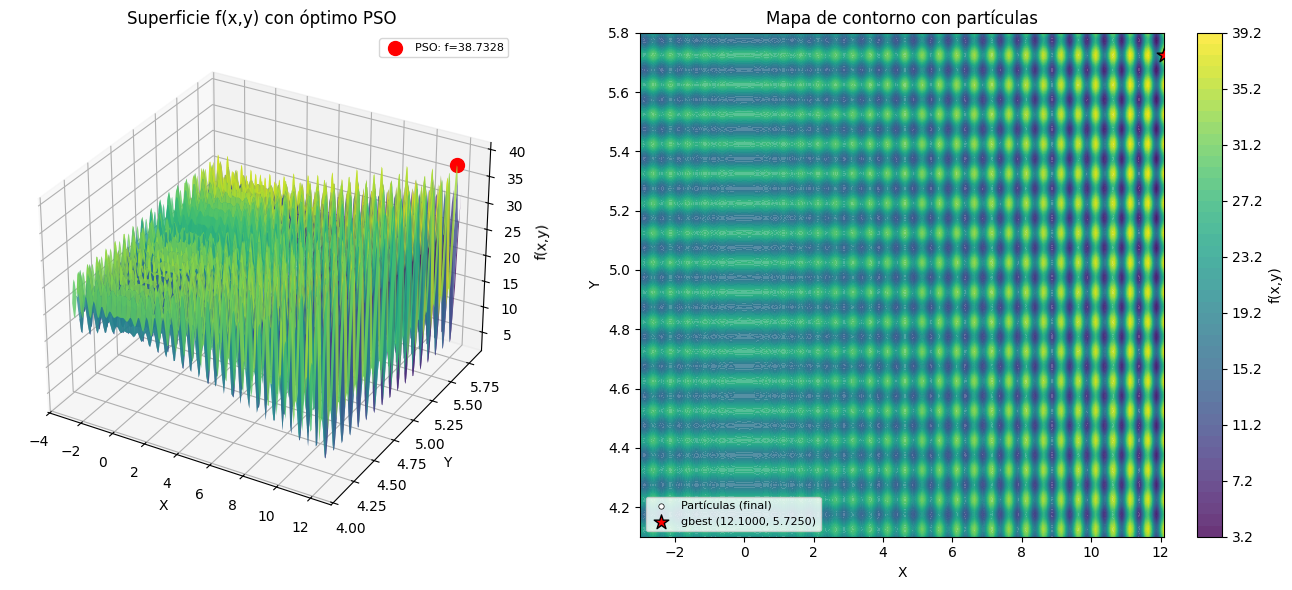

In [51]:
x_v = np.linspace(x_min, x_max, 200)
y_v = np.linspace(y_min, y_max, 200)
X, Y = np.meshgrid(x_v, y_v)
Z = f(X, Y)

fig = plt.figure(figsize=(14, 6))

# Superficie 3D
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
ax1.scatter(gbest_pos[0], gbest_pos[1], gbest_val,
            color='red', s=100, zorder=5,
            label=f'PSO: f={gbest_val:.4f}')
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('f(x,y)')
ax1.set_title('Superficie f(x,y) con óptimo PSO')
ax1.legend(fontsize=8)

# Curva de contorno + trayectoria de partículas
ax2 = fig.add_subplot(122)
contour = ax2.contourf(X, Y, Z, levels=50, cmap='viridis', alpha=0.8)
plt.colorbar(contour, ax=ax2, label='f(x,y)')

# Mostrar posiciones finales de las partículas
ax2.scatter(posiciones[:, 0], posiciones[:, 1],
            c='white', s=15, edgecolors='black', linewidths=0.5,
            label='Partículas (final)', zorder=3)
ax2.scatter(gbest_pos[0], gbest_pos[1],
            c='red', s=120, marker='*', edgecolors='black',
            label=f'gbest ({gbest_pos[0]:.4f}, {gbest_pos[1]:.4f})', zorder=4)
ax2.set_xlabel('X'); ax2.set_ylabel('Y')
ax2.set_title('Mapa de contorno con partículas')
ax2.legend(fontsize=8, loc='lower left')

plt.tight_layout()
plt.show()

### 5.2 Convergencia del PSO

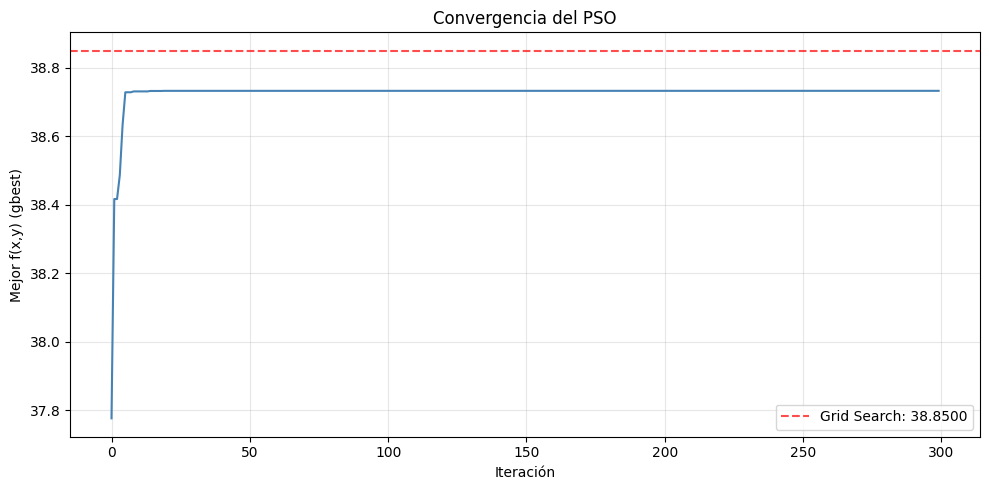

In [52]:
plt.figure(figsize=(10, 5))
plt.plot(range(N_iteraciones), historial_gbest, color='steelblue', linewidth=1.5)
plt.axhline(y=f_best_grid, color='red', linestyle='--', alpha=0.7,
            label=f'Grid Search: {f_best_grid:.4f}')
plt.xlabel('Iteración')
plt.ylabel('Mejor f(x,y) (gbest)')
plt.title('Convergencia del PSO')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.3 Evolución del enjambre sobre el mapa de contorno

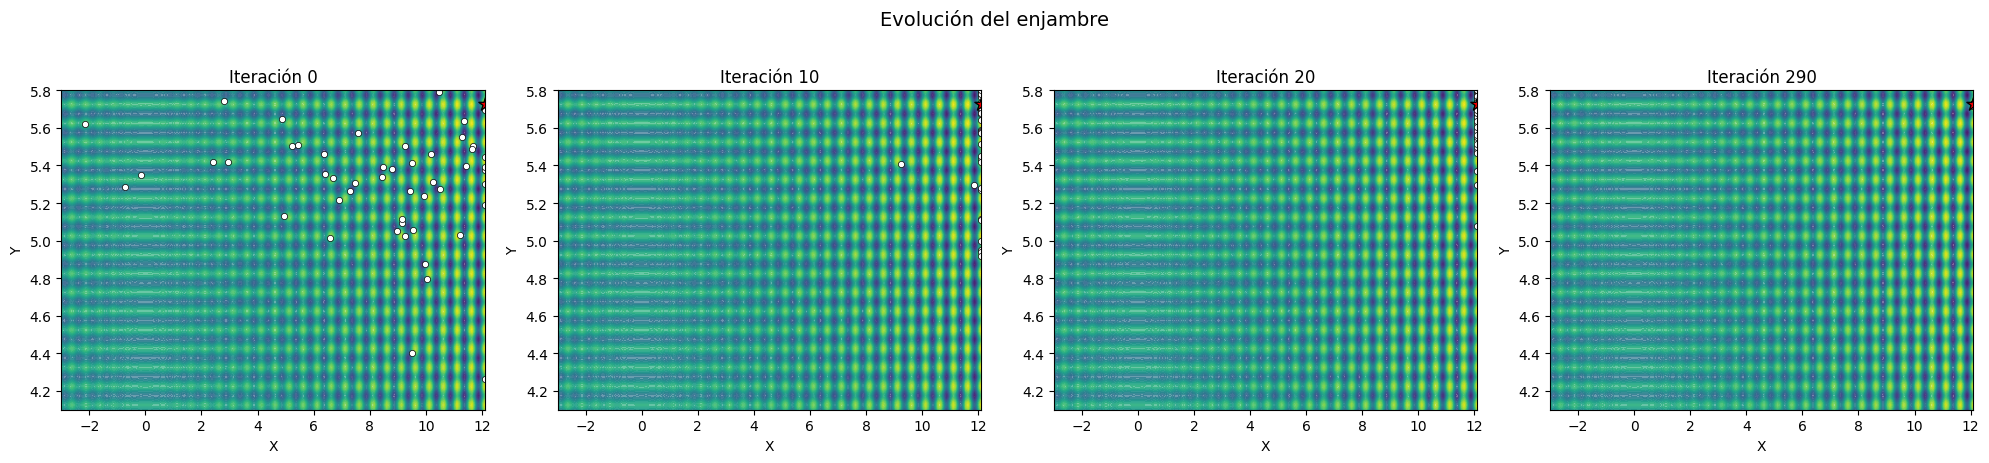

In [53]:
# Mostrar la posición de las partículas en distintas iteraciones
pasos = [0, 1, 2, len(historial_posiciones) - 1]
titulos = [f'Iteración {p * 10}' for p in pasos]

fig, axes = plt.subplots(1, len(pasos), figsize=(5 * len(pasos), 4.5))

for ax, paso, titulo in zip(axes, pasos, titulos):
    ax.contourf(X, Y, Z, levels=50, cmap='viridis', alpha=0.7)
    pos = historial_posiciones[paso]
    ax.scatter(pos[:, 0], pos[:, 1], c='white', s=20,
              edgecolors='black', linewidths=0.5)
    ax.scatter(gbest_pos[0], gbest_pos[1], c='red', s=100, marker='*',
              edgecolors='black')
    ax.set_title(titulo)
    ax.set_xlabel('X'); ax.set_ylabel('Y')

plt.suptitle('Evolución del enjambre', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Comparación de resultados

In [54]:
print("=" * 65)
print(f"{'Métrica':<30} {'Grid Search':>15} {'PSO':>15}")
print("=" * 65)
print(f"{'Mejor f(x,y)':<30} {f_best_grid:>15.6f} {gbest_val:>15.6f}")
print(f"{'x óptimo':<30} {x_best_grid:>15.6f} {gbest_pos[0]:>15.6f}")
print(f"{'y óptimo':<30} {y_best_grid:>15.6f} {gbest_pos[1]:>15.6f}")
print(f"{'Evaluaciones de f':<30} {N_puntos**2:>15,} {total_eval_pso:>15,}")
print(f"{'Tiempo (s)':<30} {t_grid:>15.4f} {t_pso:>15.4f}")
print("=" * 65)

# Diferencia porcentual
diff = abs(gbest_val - f_best_grid) / f_best_grid * 100
print(f"\nDiferencia en f(x,y): {diff:.4f}%")

# Ratio de eficiencia
ratio = (N_puntos**2) / total_eval_pso
print(f"El grid search usó {ratio:.0f}x más evaluaciones que el PSO")

Métrica                            Grid Search             PSO
Mejor f(x,y)                         38.850026       38.732806
x óptimo                             11.625765       12.100000
y óptimo                              5.725185        5.725044
Evaluaciones de f                   25,000,000          15,000
Tiempo (s)                              0.2950          0.0229

Diferencia en f(x,y): 0.3017%
El grid search usó 1667x más evaluaciones que el PSO


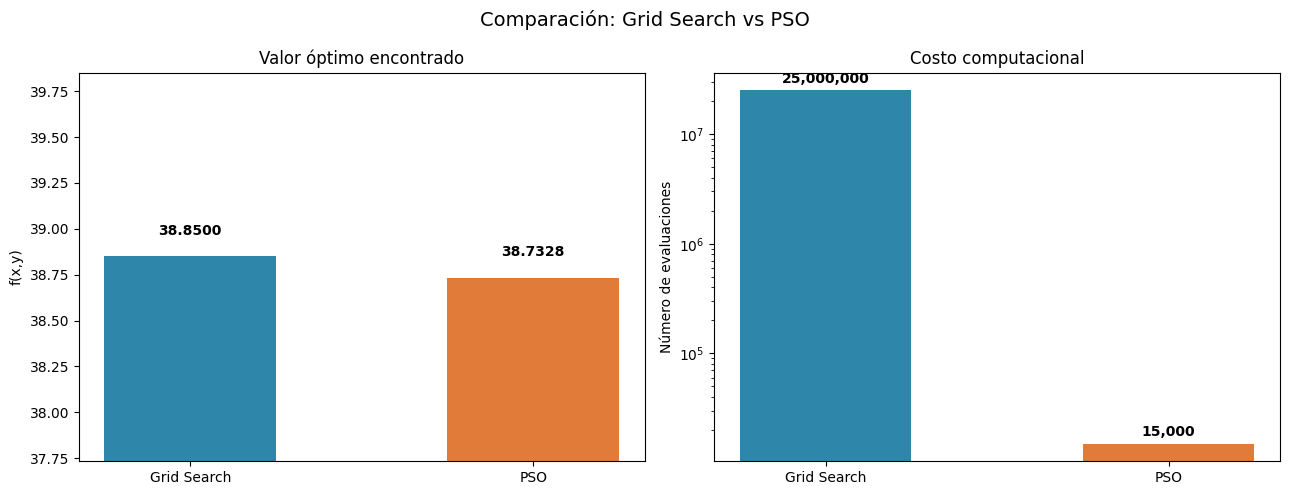

In [55]:
# Gráfica comparativa
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Barras de valor óptimo
metodos = ['Grid Search', 'PSO']
valores = [f_best_grid, gbest_val]
colores = ['#2E86AB', '#E07B39']

barras = axes[0].bar(metodos, valores, color=colores, width=0.5)
for barra in barras:
    h = barra.get_height()
    axes[0].text(barra.get_x() + barra.get_width() / 2., h + 0.1,
                f'{h:.4f}', ha='center', va='bottom', fontweight='bold')
axes[0].set_ylabel('f(x,y)')
axes[0].set_title('Valor óptimo encontrado')
axes[0].set_ylim(min(valores) - 1, max(valores) + 1)

evals = [N_puntos**2, total_eval_pso]
barras2 = axes[1].bar(metodos, evals, color=colores, width=0.5)
for barra in barras2:
    h = barra.get_height()
    axes[1].text(barra.get_x() + barra.get_width() / 2., h * 1.1,
                f'{h:,.0f}', ha='center', va='bottom', fontweight='bold')
axes[1].set_ylabel('Número de evaluaciones')
axes[1].set_title('Costo computacional')
axes[1].set_yscale('log')

plt.suptitle('Comparación: Grid Search vs PSO', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Conclusión

El PSO encuentra una solución competitiva con órdenes de magnitud menos evaluaciones.
Para funciones con muchas variables, la búsqueda exhaustiva se vuelve impráctica y las metaheurísticas como PSO son la alternativa natural.